# Object Detection using TensorFlow

## Dataset
Dataset: MNIST Handwritten Digits Dataset (TensorFlow/Keras Dataset)

## Objective
To detect and classify handwritten digits using TensorFlow. The model predicts both the digit class and its bounding box coordinates.

## Technologies Used
- Python
- TensorFlow
- NumPy
- Matplotlib
- Pillow

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Load MNIST

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


In [3]:
IMG_SIZE = 75

def create_sample(image, label):

    canvas = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    x_min = np.random.randint(0, IMG_SIZE - 28)
    y_min = np.random.randint(0, IMG_SIZE - 28)

    canvas[
        y_min:y_min+28,
        x_min:x_min+28
    ] = image

    x_max = x_min + 28
    y_max = y_min + 28

    bbox = [
        x_min / IMG_SIZE,
        y_min / IMG_SIZE,
        x_max / IMG_SIZE,
        y_max / IMG_SIZE
    ]

    return canvas, label, bbox

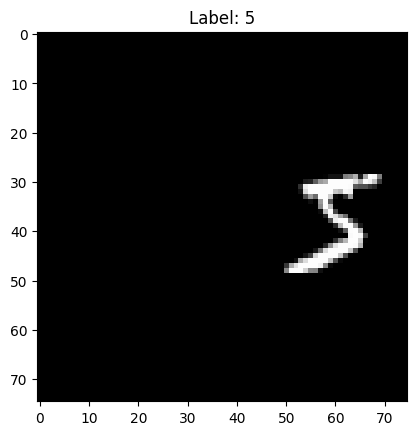

Bounding Box: [0.6133333333333333, 0.32, 0.9866666666666667, 0.6933333333333334]


In [4]:
sample_img, sample_label, sample_box = create_sample(
    x_train[0],
    y_train[0]
)

plt.imshow(sample_img, cmap="gray")
plt.title(f"Label: {sample_label}")
plt.show()

print("Bounding Box:", sample_box)

In [5]:
train_images = []
train_labels = []
train_boxes = []

for img, label in zip(x_train, y_train):

    canvas, lbl, bbox = create_sample(img, label)

    train_images.append(canvas)
    train_labels.append(lbl)
    train_boxes.append(bbox)

train_images = np.array(train_images, dtype=np.float32) / 255.0
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
train_boxes = np.array(train_boxes, dtype=np.float32)

print(train_images.shape)
print(train_labels.shape)
print(train_boxes.shape)

(60000, 75, 75)
(60000, 10)
(60000, 4)


In [6]:
test_images = []
test_labels = []
test_boxes = []

for img, label in zip(x_test, y_test):

    canvas, lbl, bbox = create_sample(img, label)

    test_images.append(canvas)
    test_labels.append(lbl)
    test_boxes.append(bbox)

test_images = np.array(test_images, dtype=np.float32) / 255.0
test_labels = tf.keras.utils.to_categorical(test_labels, 10)
test_boxes = np.array(test_boxes, dtype=np.float32)

print(test_images.shape)
print(test_labels.shape)
print(test_boxes.shape)

(10000, 75, 75)
(10000, 10)
(10000, 4)


In [7]:
train_images = train_images[..., np.newaxis]
test_images = test_images[..., np.newaxis]

print(train_images.shape)
print(test_images.shape)

(60000, 75, 75, 1)
(10000, 75, 75, 1)


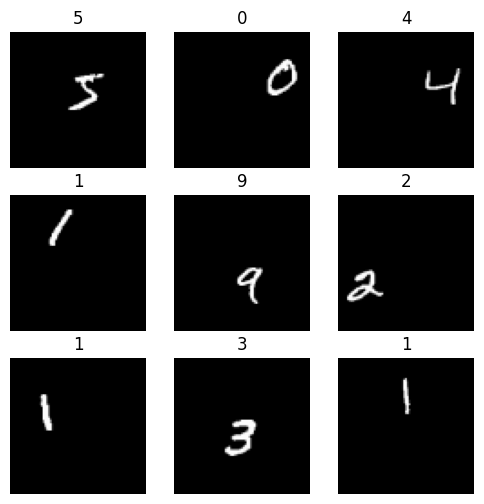

In [8]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i].squeeze(), cmap="gray")
    plt.title(np.argmax(train_labels[i]))
    plt.axis("off")

plt.show()

In [10]:
inputs = tf.keras.layers.Input(shape=(75, 75, 1))

x = tf.keras.layers.Conv2D(
    16,
    (3, 3),
    activation="relu"
)(inputs)

x = tf.keras.layers.AveragePooling2D(pool_size=(2,2))(x)

x = tf.keras.layers.Conv2D(
    32,
    (3, 3),
    activation="relu"
)(x)

x = tf.keras.layers.AveragePooling2D(pool_size=(2,2))(x)

x = tf.keras.layers.Conv2D(
    64,
    (3, 3),
    activation="relu"
)(x)

x = tf.keras.layers.AveragePooling2D(pool_size=(2,2))(x)

x = tf.keras.layers.Flatten()(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

In [11]:
classification_output = tf.keras.layers.Dense(
    10,
    activation="softmax",
    name="classification"
)(x)

bbox_output = tf.keras.layers.Dense(
    4,
    activation="sigmoid",
    name="bounding_box"
)(x)

In [12]:
model = tf.keras.Model(
    inputs=inputs,
    outputs=[
        classification_output,
        bbox_output
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 75, 75, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 73, 73,    │        160 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 36, 36,    │          0 │ conv2d_1[0][0]    │
│ (AveragePooling2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 34, 34,    │      4,640 │ average_pooling2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_1 │ (None, 17, 17,    │          0 │ conv2d_2[0][0]    │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 15, 15,    │     18,496 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_2 │ (None, 7, 7, 64)  │          0 │ conv2d_3[0][0]    │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 10)        │      1,290 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bounding_box        │ (None, 4)         │        516 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 426,638 (1.63 MB)

 Trainable params: 426,638 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer="adam",

    loss={
        "classification":
            "categorical_crossentropy",

        "bounding_box":
            "mse"
    },

    metrics={
        "classification":
            ["accuracy"],

        "bounding_box":
            ["mae"]
    }
)

In [14]:
history = model.fit(
    train_images,

    {
        "classification": train_labels,
        "bounding_box": train_boxes
    },

    validation_data=(
        test_images,

        {
            "classification": test_labels,
            "bounding_box": test_boxes
        }
    ),

    epochs=10,
    batch_size=64
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 230s 242ms/step - bounding_box_loss: 0.0051 - bounding_box_mae: 0.0514 - classification_accuracy: 0.7024 - classification_loss: 0.8711 - loss: 0.8765 - val_bounding_box_loss: 0.0025 - val_bounding_box_mae: 0.0398 - val_classification_accuracy: 0.8989 - val_classification_loss: 0.3092 - val_loss: 0.3125
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 261s 241ms/step - bounding_box_loss: 0.0019 - bounding_box_mae: 0.0347 - classification_accuracy: 0.9277 - classification_loss: 0.2380 - loss: 0.2398 - val_bounding_box_loss: 0.0016 - val_bounding_box_mae: 0.0311 - val_classification_accuracy: 0.9427 - val_classification_loss: 0.1806 - val_loss: 0.1829
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 272s 252ms/step - bounding_box_loss: 0.0015 - bounding_box_mae: 0.0303 - classification_accuracy: 0.9512 - classification_loss: 0.1575 - loss: 0.1590 - val_bounding_box_loss: 0.0013 - val_bounding_box_mae: 0.0287 - val_classification_accuracy: 0.9558 - val_classification_

In [15]:
results = model.evaluate(
    test_images,
    {
        "classification": test_labels,
        "bounding_box": test_boxes
    }
)

print(results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - bounding_box_loss: 9.5529e-04 - bounding_box_mae: 0.0242 - classification_accuracy: 0.9700 - classification_loss: 0.1092 - loss: 0.1103
[0.1103004664182663, 0.10917458683252335, 0.0009552859119139612, 0.024220788851380348, 0.9700000286102295]


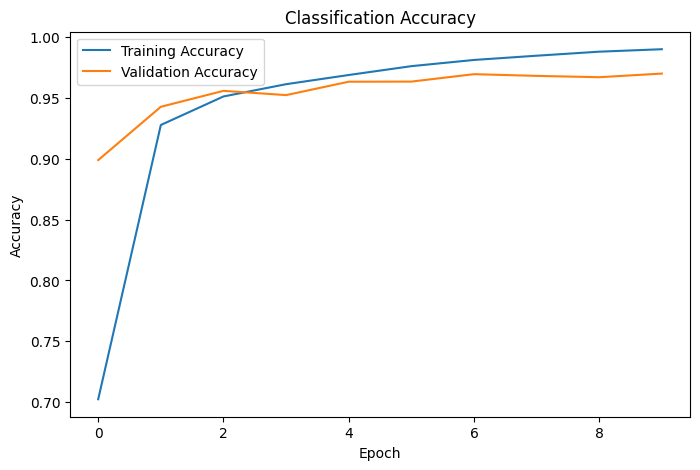

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['classification_accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_classification_accuracy'],
    label='Validation Accuracy'
)

plt.title("Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

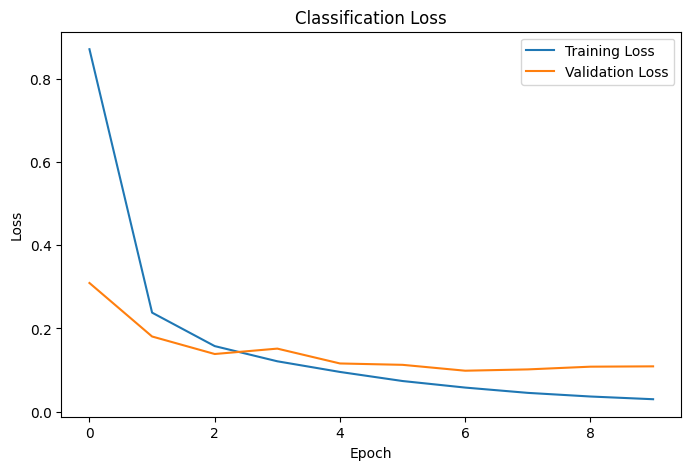

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['classification_loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_classification_loss'],
    label='Validation Loss'
)

plt.title("Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

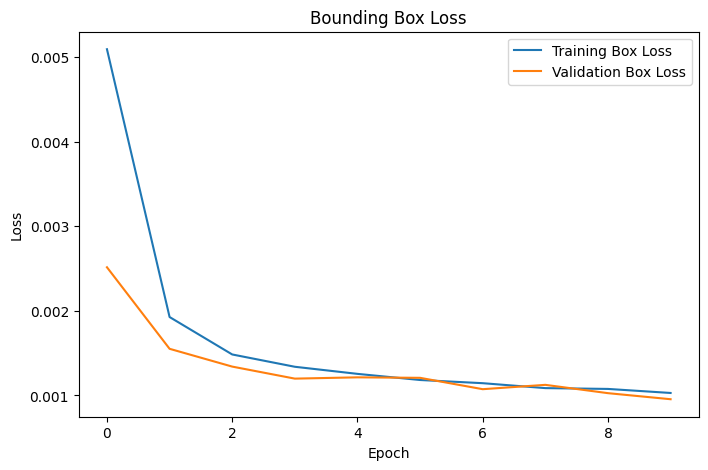

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['bounding_box_loss'],
    label='Training Box Loss'
)

plt.plot(
    history.history['val_bounding_box_loss'],
    label='Validation Box Loss'
)

plt.title("Bounding Box Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Conclusion

A TensorFlow-based Object Detection model was developed using the MNIST handwritten digits dataset.

The model performs two tasks simultaneously:

1. Digit Classification
2. Bounding Box Localization

The Convolutional Neural Network achieved approximately 97% validation accuracy while accurately predicting object locations using bounding box regression.

This demonstrates the effectiveness of multi-output neural networks for object detection tasks.